In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import subprocess
import random
from tqdm.notebook import tqdm

# Make results reproducible
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Use GPU if available, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using: cuda
GPU: Tesla T4


In [5]:
IMG_SIZE   = 128   # Size to resize images to (128x128 is faster than 256x256)
BATCH_SIZE = 32    # How many images to process at once
EPOCHS     = 30    # How many times to loop through the training data
LR         = 0.0002  # Learning rate (how fast the model learns)
L1_LAMBDA  = 100   # How much weight to give the "look like the real image" loss

print(f'Image size : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size : {BATCH_SIZE}')
print(f'Epochs     : {EPOCHS}')

Image size : 128x128
Batch size : 32
Epochs     : 30


In [6]:
# Download the dataset (only runs once)
if not os.path.exists('./edges2shoes'):
    print('Downloading dataset...')
    !wget -q --show-progress http://efrosgans.eecs.berkeley.edu/pix2pix/datasets/edges2shoes.tar.gz
    print('Extracting...')
    !tar -xzf edges2shoes.tar.gz
    print('Done!')
else:
    print('Dataset already downloaded!')

# Auto-find whichever folders have images
def find_image_folders(root):
    folders = []
    for dirpath, _, files in os.walk(root):
        if any(f.endswith('.jpg') for f in files):
            folders.append((dirpath, len([f for f in files if f.endswith('.jpg')])))
    return sorted(folders, key=lambda x: -x[1])

folders   = find_image_folders('./edges2shoes')
train_dir = folders[0][0]
val_dir   = folders[1][0] if len(folders) > 1 else folders[0][0]
print(f'Train: {train_dir} ({folders[0][1]} images)')
print(f'Val  : {val_dir}')

edges2shoes.tar.gz.   2%[                    ]  50.21M   346KB/s    eta 64m 2s ^C
Extracting...

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now
Done!
Train: ./edges2shoes/train (11543 images)
Val  : ./edges2shoes/train


In [7]:
# This class teaches PyTorch how to read our dataset
class ShoesDataset(Dataset):
    def __init__(self, folder, max_samples=None):
        # Get all jpg file names
        files = sorted([f for f in os.listdir(folder) if f.endswith('.jpg')])
        self.files  = files[:max_samples] if max_samples else files
        self.folder = folder

        # Resize + convert to tensor + normalize pixel values to [-1, 1]
        self.transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img  = Image.open(os.path.join(self.folder, self.files[idx])).convert('RGB')
        w, h = img.size
        # Split the side-by-side image into left (edge) and right (real shoe)
        edge = self.transform(img.crop((0,    0, w//2, h)))
        real = self.transform(img.crop((w//2, 0, w,    h)))
        return edge, real


# Load datasets (using a subset to keep training fast)
train_data = ShoesDataset(train_dir, max_samples=3000)
val_data   = ShoesDataset(val_dir,   max_samples=300)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=8,          shuffle=False, num_workers=2, pin_memory=True)

print(f'Training on {len(train_data)} images | Validating on {len(val_data)} images')

Training on 3000 images | Validating on 300 images


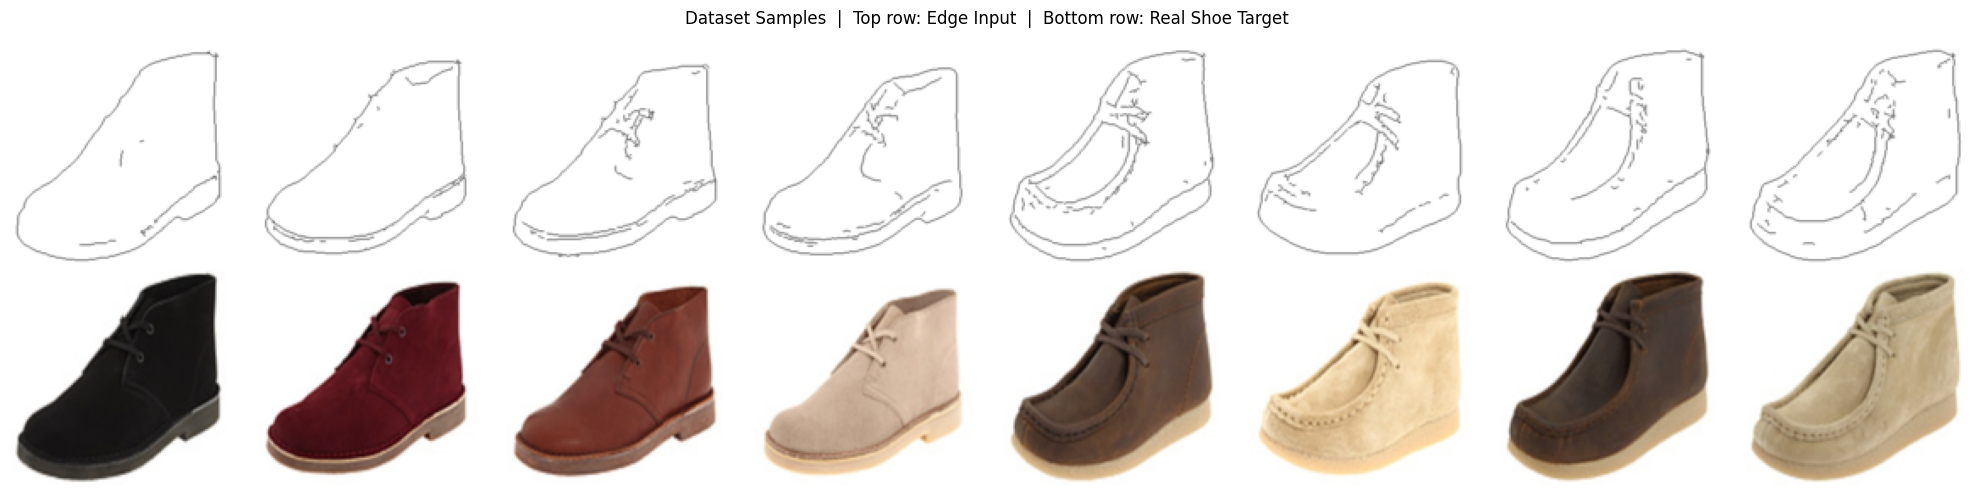

In [8]:
# Helper: convert normalized tensor back to a displayable image
def to_image(tensor):
    return (tensor * 0.5 + 0.5).clamp(0, 1)

# Show some example pairs from the dataset
edges, reals = next(iter(val_loader))

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Dataset Samples  |  Top row: Edge Input  |  Bottom row: Real Shoe Target', fontsize=12)
for i in range(8):
    axes[0, i].imshow(to_image(edges[i]).permute(1, 2, 0))
    axes[0, i].axis('off')
    axes[1, i].imshow(to_image(reals[i]).permute(1, 2, 0))
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [9]:
# One encoder step: shrinks image by 2x, learns features
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_norm=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False)]
        if use_norm:
            layers.append(nn.BatchNorm2d(out_ch))  # stabilises training
        layers.append(nn.LeakyReLU(0.2))            # activation function
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


# One decoder step: doubles image size, takes skip connection from encoder
class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU()
        ]
        if use_dropout:
            layers.append(nn.Dropout(0.5))  # randomly turns off neurons → better generalisation
        self.block = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = self.block(x)
        return torch.cat([x, skip], dim=1)  # combine with skip connection


# Full U-Net (6 levels, built for 128x128 images)
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        f = 64  # base number of filters

        # Encoder: 128→64→32→16→8→4→2
        self.down1 = DownBlock(3,   f,   use_norm=False)  # no norm on first layer
        self.down2 = DownBlock(f,   f*2)
        self.down3 = DownBlock(f*2, f*4)
        self.down4 = DownBlock(f*4, f*8)
        self.down5 = DownBlock(f*8, f*8)
        self.down6 = DownBlock(f*8, f*8)

        # Bottleneck: 2→1 (most compressed)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(f*8, f*8, kernel_size=4, stride=2, padding=1),
            nn.ReLU()
        )

        # Decoder: 1→2→4→8→16→32→64 (each step takes skip from encoder)
        self.up1 = UpBlock(f*8,    f*8, use_dropout=True)
        self.up2 = UpBlock(f*8*2,  f*8, use_dropout=True)
        self.up3 = UpBlock(f*8*2,  f*8, use_dropout=True)
        self.up4 = UpBlock(f*8*2,  f*4)
        self.up5 = UpBlock(f*4*2,  f*2)
        self.up6 = UpBlock(f*2*2,  f)

        # Final layer: output a 3-channel (RGB) image
        self.final = nn.Sequential(
            nn.ConvTranspose2d(f*2, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()  # outputs values in [-1, 1] to match our normalised images
        )

        # Initialise weights (standard GAN trick for stable training)
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
                nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, x):
        # Encode (save each output for skip connections)
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)
        d4 = self.down4(d3)
        d5 = self.down5(d4)
        d6 = self.down6(d5)
        bn = self.bottleneck(d6)

        # Decode (each step receives the matching encoder output via skip)
        u1 = self.up1(bn, d6)
        u2 = self.up2(u1, d5)
        u3 = self.up3(u2, d4)
        u4 = self.up4(u3, d3)
        u5 = self.up5(u4, d2)
        u6 = self.up6(u5, d1)
        return self.final(u6)


G = UNetGenerator().to(device)
print(f'Generator has {sum(p.numel() for p in G.parameters()):,} parameters')

# Quick check: does it produce the right output shape?
test_input = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).to(device)
print(f'Input shape:  {test_input.shape}')
print(f'Output shape: {G(test_input).shape}')  # should be (1, 3, 128, 128)

Generator has 41,829,507 parameters
Input shape:  torch.Size([1, 3, 128, 128])
Output shape: torch.Size([1, 3, 128, 128])


In [10]:
class PatchGANDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Takes 6 channels: 3 (edge) + 3 (real or fake shoe)
        self.model = nn.Sequential(
            # Layer 1: no BatchNorm on first layer
            nn.Conv2d(6, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            # Layer 2
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            # Layer 3
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            # Layer 4 (stride=1 to keep spatial size for patch output)
            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),

            # Output: 1-channel patch map (each value = real/fake score for that patch)
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1)
        )

        # Initialise weights
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight, 0.0, 0.02)

    def forward(self, edge, shoe):
        # Stack edge and shoe together along the channel dimension
        combined = torch.cat([edge, shoe], dim=1)
        return self.model(combined)


D = PatchGANDiscriminator().to(device)
print(f'Discriminator has {sum(p.numel() for p in D.parameters()):,} parameters')

# Check output shape (should be a small spatial map, not a single number)
patch_out = D(test_input, test_input)
print(f'PatchGAN output shape: {patch_out.shape}')  # e.g. (1, 1, 13, 13)

Discriminator has 2,768,705 parameters
PatchGAN output shape: torch.Size([1, 1, 14, 14])


In [11]:
# Loss functions
adversarial_loss = nn.BCEWithLogitsLoss()  # for real/fake classification
reconstruction_loss = nn.L1Loss()          # for pixel-level similarity

# Optimizers (Adam with beta1=0.5 is standard for GANs)
opt_G = optim.Adam(G.parameters(), lr=LR, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR, betas=(0.5, 0.999))

# Figure out PatchGAN output size (needed for labels)
patch_h = D(test_input, test_input).shape[2]
patch_w = D(test_input, test_input).shape[3]
print(f'Patch label size: {patch_h}x{patch_w}')
print('Ready to train!')

Patch label size: 14x14
Ready to train!


In [ ]:
G_losses, D_losses, L1_losses = [], [], []

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    ep_G = ep_D = ep_L1 = 0.0

    loop = tqdm(train_loader, desc=f'Epoch [{epoch}/{EPOCHS}]', leave=False)

    for edge_img, real_img in loop:
        edge_img = edge_img.to(device)
        real_img = real_img.to(device)
        bs = edge_img.size(0)

        # Labels: 1 = real, 0 = fake (sized to match patch output)
        real_label = torch.ones (bs, 1, patch_h, patch_w, device=device)
        fake_label = torch.zeros(bs, 1, patch_h, patch_w, device=device)

        # ── Step 1: Train Discriminator ──────────────────────────────────────
        # Goal: correctly identify real pairs as real, fake pairs as fake
        fake_img = G(edge_img).detach()  # generate fake (detach = don't update G yet)

        loss_D = (
            adversarial_loss(D(edge_img, real_img), real_label) +   # real pair → 1
            adversarial_loss(D(edge_img, fake_img), fake_label)     # fake pair → 0
        ) * 0.5

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # ── Step 2: Train Generator ──────────────────────────────────────────
        # Goal: fool D into thinking fakes are real, AND look like the real image
        fake_img  = G(edge_img)  # generate again (this time we DO update G)

        loss_adv  = adversarial_loss(D(edge_img, fake_img), real_label)  # fool D
        loss_L1   = reconstruction_loss(fake_img, real_img) * L1_LAMBDA  # match real
        loss_G    = loss_adv + loss_L1

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        ep_G  += loss_adv.item()
        ep_D  += loss_D.item()
        ep_L1 += loss_L1.item() / L1_LAMBDA

        loop.set_postfix(G=f'{loss_adv.item():.3f}', D=f'{loss_D.item():.3f}')

    # Record average losses for this epoch
    n = len(train_loader)
    G_losses.append(ep_G / n)
    D_losses.append(ep_D / n)
    L1_losses.append(ep_L1 / n)

    print(f'Epoch [{epoch:3d}/{EPOCHS}]  G={ep_G/n:.4f}  D={ep_D/n:.4f}  L1={ep_L1/n:.4f}')

print('\nTraining complete!')

Epoch [1/30]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [  1/30]  G=2.1904  D=0.3648  L1=0.3204


Epoch [2/30]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [  2/30]  G=1.8950  D=0.3769  L1=0.1901


Epoch [3/30]:   0%|          | 0/94 [00:00<?, ?it/s]

...

Epoch [26/30]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [ 26/30]  G=1.0713  D=0.5878  L1=0.0740


Epoch [27/30]:   0%|          | 0/94 [00:00<?, ?it/s]

Epoch [ 27/30]  G=1.0917  D=0.5912  L1=0.0723


Epoch [28/30]:   0%|          | 0/94 [00:00<?, ?it/s]

In [ ]:
# Plot how the losses changed over training
# G loss going down = generator getting better at fooling D
# D loss staying ~0.5 = D and G are balanced (good!)
# L1 loss going down = generated images looking more like real ones

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Training Loss Curves', fontsize=13)

titles  = ['Generator Adversarial Loss', 'Discriminator Loss', 'L1 Reconstruction Loss']
data    = [G_losses, D_losses, L1_losses]
colors  = ['royalblue', 'tomato', 'seagreen']

for ax, title, vals, color in zip(axes, titles, data, colors):
    ax.plot(vals, color=color, linewidth=2)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Show what Pix2Pix actually generates on validation images
G.eval()
val_edges, val_reals = next(iter(val_loader))
val_edges_gpu = val_edges.to(device)

with torch.no_grad():
    val_fakes = G(val_edges_gpu).cpu()

n = 8
fig, axes = plt.subplots(3, n, figsize=(20, 7))
fig.suptitle('Pix2Pix Results  |  Row 1: Edge Input  |  Row 2: Generated  |  Row 3: Real Target',
             fontsize=12, fontweight='bold')

for col in range(n):
    for row, imgs in enumerate([val_edges, val_fakes, val_reals]):
        axes[row, col].imshow(np.clip(to_image(imgs[col]).permute(1, 2, 0).numpy(), 0, 1))
        axes[row, col].axis('off')

axes[0, 0].set_ylabel('Edge\nInput',    fontsize=9, rotation=0, labelpad=50, va='center')
axes[1, 0].set_ylabel('Generated\nShoe', fontsize=9, rotation=0, labelpad=50, va='center')
axes[2, 0].set_ylabel('Real\nTarget',   fontsize=9, rotation=0, labelpad=50, va='center')
plt.tight_layout()
plt.show()

In [ ]:
# Same U-Net architecture as Generator, but trained with simple MSE+L1 loss only
class BaselineCNN(nn.Module):
    def __init__(self):
        super().__init__()
        f = 64
        # Encoder
        self.e1 = nn.Sequential(nn.Conv2d(3,   f,   4, 2, 1), nn.LeakyReLU(0.2))
        self.e2 = nn.Sequential(nn.Conv2d(f,   f*2, 4, 2, 1), nn.BatchNorm2d(f*2),  nn.LeakyReLU(0.2))
        self.e3 = nn.Sequential(nn.Conv2d(f*2, f*4, 4, 2, 1), nn.BatchNorm2d(f*4),  nn.LeakyReLU(0.2))
        self.e4 = nn.Sequential(nn.Conv2d(f*4, f*8, 4, 2, 1), nn.BatchNorm2d(f*8),  nn.LeakyReLU(0.2))
        self.bn = nn.Sequential(nn.Conv2d(f*8, f*8, 4, 2, 1), nn.ReLU())
        # Decoder (with skip connections)
        self.d1 = nn.Sequential(nn.ConvTranspose2d(f*8,   f*8, 4, 2, 1), nn.BatchNorm2d(f*8), nn.ReLU(), nn.Dropout(0.5))
        self.d2 = nn.Sequential(nn.ConvTranspose2d(f*8*2, f*4, 4, 2, 1), nn.BatchNorm2d(f*4), nn.ReLU())
        self.d3 = nn.Sequential(nn.ConvTranspose2d(f*4*2, f*2, 4, 2, 1), nn.BatchNorm2d(f*2), nn.ReLU())
        self.d4 = nn.Sequential(nn.ConvTranspose2d(f*2*2, f,   4, 2, 1), nn.BatchNorm2d(f),   nn.ReLU())
        self.out= nn.Sequential(nn.ConvTranspose2d(f*2,   3,   4, 2, 1), nn.Tanh())

    def forward(self, x):
        e1 = self.e1(x);  e2 = self.e2(e1);  e3 = self.e3(e2);  e4 = self.e4(e3)
        b  = self.bn(e4)
        d1 = self.d1(b)
        d2 = self.d2(torch.cat([d1, e4], 1))
        d3 = self.d3(torch.cat([d2, e3], 1))
        d4 = self.d4(torch.cat([d3, e2], 1))
        return self.out(torch.cat([d4, e1], 1))


baseline = BaselineCNN().to(device)
opt_b    = optim.Adam(baseline.parameters(), lr=LR, betas=(0.5, 0.999))
print(f'Baseline CNN has {sum(p.numel() for p in baseline.parameters()):,} parameters')
print('Training for 20 epochs...')

baseline_losses = []
for epoch in range(1, 21):
    baseline.train()
    ep_loss = 0.0
    for edge_b, real_b in train_loader:
        edge_b, real_b = edge_b.to(device), real_b.to(device)
        out  = baseline(edge_b)
        loss = nn.MSELoss()(out, real_b) + 10.0 * nn.L1Loss()(out, real_b)
        opt_b.zero_grad(); loss.backward(); opt_b.step()
        ep_loss += loss.item()
    avg = ep_loss / len(train_loader)
    baseline_losses.append(avg)
    if epoch % 5 == 0:
        print(f'  Epoch [{epoch}/20]  Loss: {avg:.4f}')

print('Baseline training done!')

In [ ]:
# Side-by-side visual comparison: edge → baseline → pix2pix → real
baseline.eval(); G.eval()
val_edges_b, val_reals_b = next(iter(val_loader))
val_edges_gpu = val_edges_b.to(device)

with torch.no_grad():
    baseline_out = baseline(val_edges_gpu).cpu()
    pix2pix_out  = G(val_edges_gpu).cpu()

n = 6
fig, axes = plt.subplots(4, n, figsize=(18, 10))
fig.suptitle('Task 5: Pix2Pix GAN vs Baseline CNN', fontsize=14, fontweight='bold')

row_data   = [val_edges_b, baseline_out, pix2pix_out, val_reals_b]
row_labels = ['Input\n(Edge)', 'Baseline\nCNN', 'Pix2Pix\nGAN', 'Target\n(Real)']
row_colors = ['black', 'darkorange', 'royalblue', 'green']

for row, (data, label, color) in enumerate(zip(row_data, row_labels, row_colors)):
    for col in range(n):
        axes[row, col].imshow(np.clip(to_image(data[col]).permute(1, 2, 0).numpy(), 0, 1))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=10, color=color, rotation=0,
                             labelpad=55, va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Compute MSE, L1, and PSNR on the validation set for both models
# PSNR = Peak Signal-to-Noise Ratio: higher = better image quality

def compute_metrics(model, loader):
    model.eval()
    mse_list, l1_list = [], []
    with torch.no_grad():
        for edge_b, real_b in loader:
            edge_b, real_b = edge_b.to(device), real_b.to(device)
            out = model(edge_b)
            for i in range(edge_b.size(0)):
                mse_list.append(((out[i] - real_b[i])**2).mean().item())
                l1_list.append((out[i] - real_b[i]).abs().mean().item())
    mse  = np.mean(mse_list)
    l1   = np.mean(l1_list)
    psnr = 10 * np.log10(4.0 / mse)  # range is [-1,1] so max signal = 4
    return mse, l1, psnr

base_mse, base_l1, base_psnr = compute_metrics(baseline, val_loader)
pix_mse,  pix_l1,  pix_psnr  = compute_metrics(G,        val_loader)

print('=' * 52)
print(f'{"Metric":<15} {"Baseline CNN":>16} {"Pix2Pix GAN":>16}')
print('=' * 52)
print(f'{"MSE  (↓ better)":<15} {base_mse:>16.5f} {pix_mse:>16.5f}')
print(f'{"L1   (↓ better)":<15} {base_l1:>16.5f} {pix_l1:>16.5f}')
print(f'{"PSNR (↑ better)":<15} {base_psnr:>16.2f} {pix_psnr:>16.2f}')
print('=' * 52)
print(f'  Winner → {"Pix2Pix GAN" if pix_psnr > base_psnr else "Baseline CNN"}')

# Bar chart comparison
x, width = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - width/2, [base_mse, base_l1, base_psnr], width, label='Baseline CNN', color='darkorange', alpha=0.85)
b2 = ax.bar(x + width/2, [pix_mse,  pix_l1,  pix_psnr],  width, label='Pix2Pix GAN', color='royalblue',  alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['MSE ↓', 'L1 ↓', 'PSNR ↑ (dB)'], fontsize=11)
ax.set_title('Pix2Pix GAN vs Baseline CNN – Metric Comparison', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()